In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def create_geometry(Nx=401, Ny=81):
    L = 2.2
    H = 0.41

    x = np.linspace(0.0, L, Nx)
    y = np.linspace(0.0, H, Ny)
    dx = x[1] - x[0]
    dy = y[1] - y[0]

    X, Y = np.meshgrid(x, y, indexing="ij")

    # cylinder from figure
    D = 0.1
    R = D / 2.0
    xc, yc = 0.2, 0.2

    cylinder = (X - xc) ** 2 + (Y - yc) ** 2 <= R ** 2

    geom = {
        "L": L,
        "H": H,
        "Nx": Nx,
        "Ny": Ny,
        "x": x,
        "y": y,
        "X": X,
        "Y": Y,
        "dx": dx,
        "dy": dy,
        "D": D,
        "R": R,
        "xc": xc,
        "yc": yc,
        "cylinder": cylinder,
    }
    return geom

In [4]:
def create_parameters(Re=100.0, nu=0.01, rho=1.0, dt=1e-4,
                      nsteps=8000, poisson_iters=100):
    D = 0.1
    U_in = Re * nu / D
    return {
        "Re": Re,
        "U_in": U_in,
        "rho": rho,
        "nu": nu,
        "dt": dt,
        "nsteps": nsteps,
        "poisson_iters": poisson_iters,
    }

In [5]:
def initialize_fields(geom):
    Nx, Ny = geom["Nx"], geom["Ny"]
    u = np.zeros((Nx, Ny))
    v = np.zeros((Nx, Ny))
    p = np.zeros((Nx, Ny))
    return u, v, p

In [6]:
def apply_velocity_bc(u, v, geom, params):
    cylinder = geom["cylinder"]
    U_in = params["U_in"]

    # inlet at x = 0
    u[0, :] = U_in
    v[0, :] = 0.0

    # outlet at x = L: zero normal gradient
    u[-1, :] = u[-2, :]
    v[-1, :] = v[-2, :]

    # top and bottom walls: no-slip
    u[:, 0] = 0.0
    u[:, -1] = 0.0
    v[:, 0] = 0.0
    v[:, -1] = 0.0

    # cylinder: no-slip
    u[cylinder] = 0.0
    v[cylinder] = 0.0


In [7]:
def apply_pressure_bc(p):
    # left boundary: dp/dx = 0
    p[0, :] = p[1, :]

    # top and bottom: dp/dy = 0
    p[:, 0] = p[:, 1]
    p[:, -1] = p[:, -2]

    # outlet reference pressure
    p[-1, :] = 0.0


In [8]:
def laplacian(f, dx, dy):
    return (
        (f[2:, 1:-1] - 2.0 * f[1:-1, 1:-1] + f[:-2, 1:-1]) / dx**2
        + (f[1:-1, 2:] - 2.0 * f[1:-1, 1:-1] + f[1:-1, :-2]) / dy**2
    )


def upwind_convection(u, v, dx, dy):
    u_c = u[1:-1, 1:-1]
    v_c = v[1:-1, 1:-1]

    # d(u)/dx and d(u)/dy
    du_dx = np.where(
        u_c > 0.0,
        (u[1:-1, 1:-1] - u[:-2, 1:-1]) / dx,
        (u[2:, 1:-1] - u[1:-1, 1:-1]) / dx
    )
    du_dy = np.where(
        v_c > 0.0,
        (u[1:-1, 1:-1] - u[1:-1, :-2]) / dy,
        (u[1:-1, 2:] - u[1:-1, 1:-1]) / dy
    )

    # d(v)/dx and d(v)/dy
    dv_dx = np.where(
        u_c > 0.0,
        (v[1:-1, 1:-1] - v[:-2, 1:-1]) / dx,
        (v[2:, 1:-1] - v[1:-1, 1:-1]) / dx
    )
    dv_dy = np.where(
        v_c > 0.0,
        (v[1:-1, 1:-1] - v[1:-1, :-2]) / dy,
        (v[1:-1, 2:] - v[1:-1, 1:-1]) / dy
    )

    conv_u = u_c * du_dx + v_c * du_dy
    conv_v = u_c * dv_dx + v_c * dv_dy
    return conv_u, conv_v


def divergence(u, v, dx, dy):
    return (
        (u[2:, 1:-1] - u[:-2, 1:-1]) / (2.0 * dx)
        + (v[1:-1, 2:] - v[1:-1, :-2]) / (2.0 * dy)
    )


def vorticity(u, v, dx, dy):
    return (
        (v[2:, 1:-1] - v[:-2, 1:-1]) / (2.0 * dx)
        - (u[1:-1, 2:] - u[1:-1, :-2]) / (2.0 * dy)
    )

In [9]:
def intermediate_velocity(u, v, geom, params):
    dx, dy = geom["dx"], geom["dy"]
    nu, dt = params["nu"], params["dt"]

    conv_u, conv_v = upwind_convection(u, v, dx, dy)
    lap_u = laplacian(u, dx, dy)
    lap_v = laplacian(v, dx, dy)

    us = u.copy()
    vs = v.copy()

    us[1:-1, 1:-1] = u[1:-1, 1:-1] + dt * (-conv_u + nu * lap_u)
    vs[1:-1, 1:-1] = v[1:-1, 1:-1] + dt * (-conv_v + nu * lap_v)

    apply_velocity_bc(us, vs, geom, params)
    return us, vs


def pressure_rhs(us, vs, geom, params):
    dx, dy = geom["dx"], geom["dy"]
    rho, dt = params["rho"], params["dt"]

    rhs = np.zeros_like(us)
    rhs[1:-1, 1:-1] = (rho / dt) * (
        (us[2:, 1:-1] - us[:-2, 1:-1]) / (2.0 * dx)
        + (vs[1:-1, 2:] - vs[1:-1, :-2]) / (2.0 * dy)
    )
    return rhs


def solve_pressure(p, rhs, geom, params):
    dx, dy = geom["dx"], geom["dy"]
    cylinder = geom["cylinder"]
    poisson_iters = params["poisson_iters"]

    for _ in range(poisson_iters):
        p_old = p.copy()

        p[1:-1, 1:-1] = (
            (p_old[2:, 1:-1] + p_old[:-2, 1:-1]) * dy**2
            + (p_old[1:-1, 2:] + p_old[1:-1, :-2]) * dx**2
            - rhs[1:-1, 1:-1] * dx**2 * dy**2
        ) / (2.0 * (dx**2 + dy**2))

        apply_pressure_bc(p)
        p[cylinder] = 0.0

    return p


def correct_velocity(us, vs, p, geom, params):
    dx, dy = geom["dx"], geom["dy"]
    rho, dt = params["rho"], params["dt"]

    u = us.copy()
    v = vs.copy()

    u[1:-1, 1:-1] = us[1:-1, 1:-1] - (dt / rho) * (
        (p[2:, 1:-1] - p[:-2, 1:-1]) / (2.0 * dx)
    )
    v[1:-1, 1:-1] = vs[1:-1, 1:-1] - (dt / rho) * (
        (p[1:-1, 2:] - p[1:-1, :-2]) / (2.0 * dy)
    )

    apply_velocity_bc(u, v, geom, params)
    return u, v


In [10]:
def solve_fd_karman(geom, params, plot_every=1000, verbose_every=200):
    u, v, p = initialize_fields(geom)
    apply_velocity_bc(u, v, geom, params)

    for step in range(params["nsteps"]):
        us, vs = intermediate_velocity(u, v, geom, params)
        rhs = pressure_rhs(us, vs, geom, params)
        p = solve_pressure(p, rhs, geom, params)
        u, v = correct_velocity(us, vs, p, geom, params)

        if step % verbose_every == 0:
            div = divergence(u, v, geom["dx"], geom["dy"])
            print(
                f"step={step:5d}, "
                f"max|div|={np.max(np.abs(div)):.3e}, "
                f"umax={np.max(np.abs(u)):.3f}, "
                f"vmax={np.max(np.abs(v)):.3f}"
            )

        if plot_every is not None and step % plot_every == 0 and step > 0:
            plot_vorticity(u, v, geom, step=step)

    return u, v, p


In [11]:
def plot_geometry(geom):
    x = geom["x"]
    y = geom["y"]
    xc, yc, R = geom["xc"], geom["yc"], geom["R"]

    plt.figure(figsize=(12, 2.8))
    plt.plot([0, geom["L"], geom["L"], 0, 0],
             [0, 0, geom["H"], geom["H"], 0], "k-")

    theta = np.linspace(0, 2 * np.pi, 300)
    plt.fill(xc + R * np.cos(theta), yc + R * np.sin(theta), color="gray")

    plt.xlim(-0.02, geom["L"] + 0.02)
    plt.ylim(-0.02, geom["H"] + 0.02)
    plt.gca().set_aspect("equal")
    plt.title("Geometry from the picture")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.tight_layout()
    plt.show()


def plot_vorticity(u, v, geom, step=None, vmax=8.0):
    omega = vorticity(u, v, geom["dx"], geom["dy"])

    plt.figure(figsize=(12, 3))
    plt.imshow(
        omega.T,
        extent=[0, geom["L"], 0, geom["H"]],
        origin="lower",
        cmap="RdBu",
        vmin=-vmax,
        vmax=vmax,
        aspect="auto"
    )

    theta = np.linspace(0, 2 * np.pi, 300)
    plt.plot(
        geom["xc"] + geom["R"] * np.cos(theta),
        geom["yc"] + geom["R"] * np.sin(theta),
        "k", lw=1.5
    )

    plt.colorbar(label="vorticity")
    title = "Vorticity"
    if step is not None:
        title += f" at step {step}"
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.tight_layout()
    plt.show()


def plot_speed(u, v, geom, step=None):
    speed = np.sqrt(u**2 + v**2)

    plt.figure(figsize=(12, 3))
    plt.imshow(
        speed.T,
        extent=[0, geom["L"], 0, geom["H"]],
        origin="lower",
        cmap="viridis",
        aspect="auto"
    )
    plt.colorbar(label="|u|")
    plt.title("Speed" if step is None else f"Speed at step {step}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.tight_layout()
    plt.show()


In [12]:
def check_cfl_stability(u, v, dx, dy, dt, nu,
                        cfl_limit=0.5, diff_limit=0.5):
    """
    Check if current dt satisfies CFL conditions.

    Returns:
        is_stable (bool)
        cfl_conv (float)
        cfl_diff (float)
    """

    umax = np.max(np.abs(u))
    vmax = np.max(np.abs(v))

    eps = 1e-12  # avoid division by zero

    # convective CFL numbers
    cfl_x = umax * dt / dx
    cfl_y = vmax * dt / dy
    cfl_conv = max(cfl_x, cfl_y)

    # diffusive CFL number
    cfl_diff = 2 * nu * dt * (1/dx**2 + 1/dy**2)

    is_stable = (cfl_conv < cfl_limit) and (cfl_diff < diff_limit)

    return is_stable, cfl_conv, cfl_diff

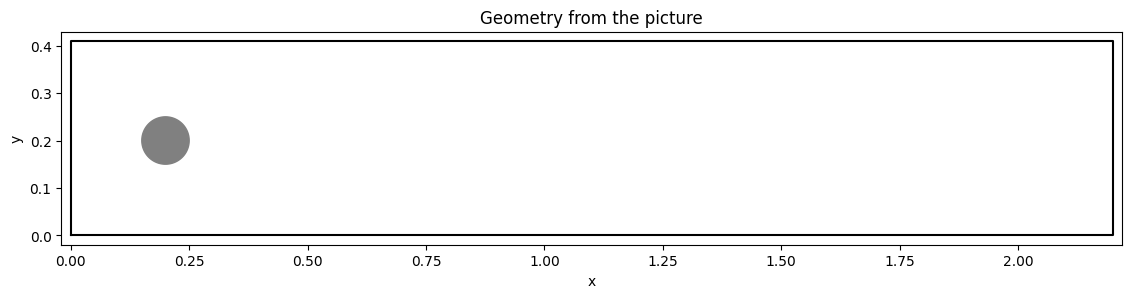

step=    0, max|div|=1.004e+03, umax=19.000, vmax=0.000
step=  200, max|div|=3.285e+03, umax=25.684, vmax=22.517
step=  400, max|div|=2.454e+03, umax=25.528, vmax=14.750
step=  600, max|div|=2.012e+03, umax=25.098, vmax=9.036
step=  800, max|div|=1.811e+03, umax=24.989, vmax=5.817
step= 1000, max|div|=1.736e+03, umax=25.097, vmax=5.589
step= 1200, max|div|=1.701e+03, umax=25.393, vmax=5.840
step= 1400, max|div|=1.682e+03, umax=25.562, vmax=5.977
step= 1600, max|div|=1.675e+03, umax=25.694, vmax=6.047
step= 1800, max|div|=1.672e+03, umax=25.771, vmax=6.073
step= 2000, max|div|=1.672e+03, umax=25.756, vmax=6.070


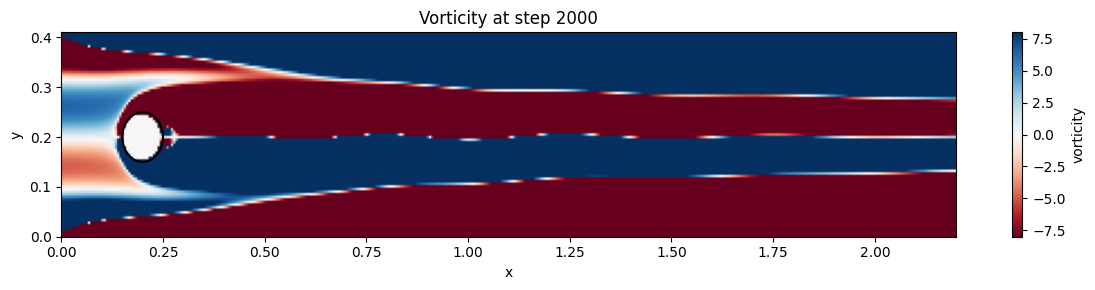

step= 2200, max|div|=1.673e+03, umax=25.709, vmax=6.058
step= 2400, max|div|=1.674e+03, umax=25.666, vmax=6.051
step= 2600, max|div|=1.674e+03, umax=25.618, vmax=6.046
step= 2800, max|div|=1.675e+03, umax=25.627, vmax=6.042
step= 3000, max|div|=1.675e+03, umax=25.709, vmax=6.043
step= 3200, max|div|=1.675e+03, umax=25.780, vmax=6.049
step= 3400, max|div|=1.674e+03, umax=25.825, vmax=6.051
step= 3600, max|div|=1.673e+03, umax=25.830, vmax=6.049
step= 3800, max|div|=1.673e+03, umax=25.798, vmax=6.050
step= 4000, max|div|=1.672e+03, umax=25.774, vmax=6.055


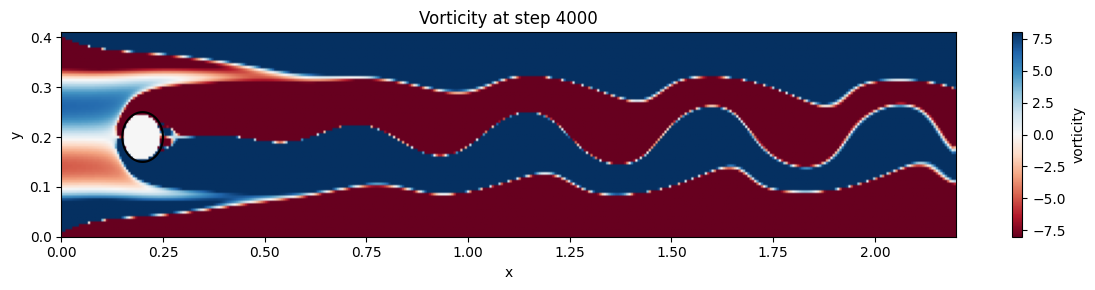

step= 4200, max|div|=1.672e+03, umax=25.837, vmax=6.060
step= 4400, max|div|=1.673e+03, umax=25.941, vmax=6.065
step= 4600, max|div|=1.674e+03, umax=26.013, vmax=6.071
step= 4800, max|div|=1.674e+03, umax=26.050, vmax=6.075
step= 5000, max|div|=1.674e+03, umax=26.062, vmax=6.073
step= 5200, max|div|=1.673e+03, umax=26.062, vmax=6.062
step= 5400, max|div|=1.673e+03, umax=26.045, vmax=6.048
step= 5600, max|div|=1.673e+03, umax=26.061, vmax=6.038
step= 5800, max|div|=1.673e+03, umax=26.055, vmax=6.037
CFL stability check result:  True
Convective CFL number:  0.47319681898215127
Diffusive CFL number:  0.14226085417475828


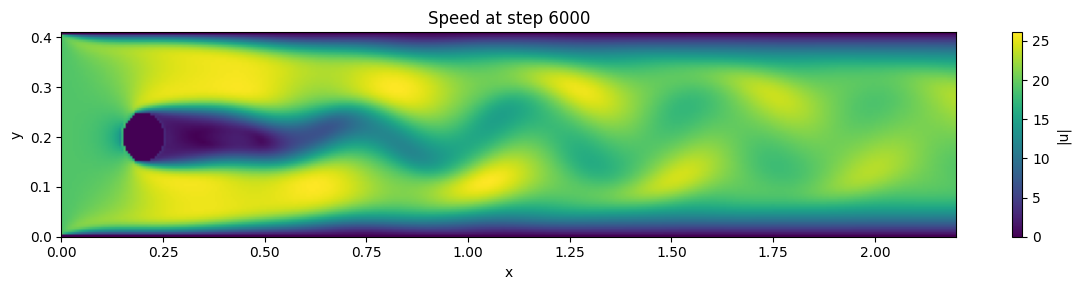

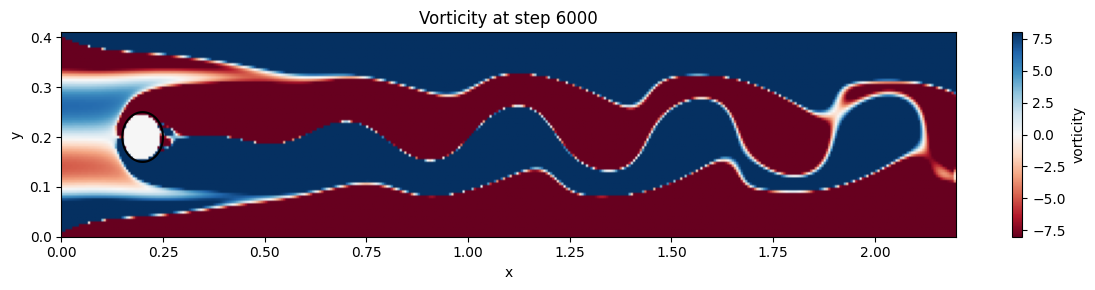

In [16]:
geom = create_geometry(Nx=401, Ny=81)
params = create_parameters(
        Re=190.0,        
        nu=0.01,
        rho=1.0,
        dt=1e-4,         
        nsteps=6000,
        poisson_iters=100
    )

plot_geometry(geom)

u, v, p = solve_fd_karman(
        geom,
        params,
        plot_every=2000,
        verbose_every=200
    )
is_stable, cfl_conv, cfl_diff = check_cfl_stability(u, v, geom["dx"], geom["dy"], params["dt"], params["nu"])
print("CFL stability check result: ", is_stable)
print("Convective CFL number: ", cfl_conv)
print("Diffusive CFL number: ", cfl_diff)
plot_speed(u, v, geom, step=params["nsteps"])
plot_vorticity(u, v, geom, step=params["nsteps"])